# Structural Signatures of Reasoning in LLM Chain-of-Thought Traces
### *Testing Whether Reasoning Traces Reflect Genuine Inferential Process*

**Pipeline:**
1. Data loading & segmentation  
2. Step classification (Qwen3-8B, 4-bit)  
3. Transition matrix analysis (bigrams / n-grams)  
4. Correctness prediction (BoW baseline + structural features)  
5. Model comparison — Gemini vs DeepSeek  
6. Domain-specific analysis  
7. Hidden Markov Models  
8. Sequential pattern mining (PrefixSpan)  
9. Trace editing interventions

> **Note on model name:** You specified `Qwen/Qwen3.5-9B`; the closest
> available public checkpoint is `Qwen/Qwen3-8B` (8B instruct, native
> thinking-mode support). Update `MODEL_NAME` below if another checkpoint
> is preferred.

## 0. Installation

In [1]:
! pip install -q datasets transformers accelerate bitsandbytes \
    hmmlearn mlxtend seaborn scipy statsmodels sentence-transformers \
    torch tqdm

## 1. Imports & Config

In [2]:
import os, re, json, warnings, pickle
from collections import Counter, defaultdict
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from hmmlearn.hmm import CategoricalHMM
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth
from datasets import load_dataset

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
FIGSIZE = (13, 5)

# ── constants ──────────────────────────────────────────────────────────────
LABELS       = ["\"Setup\"", "\"Computation\"", "\"Verification\"", "\"Backtrack\"", "\"Exploration\"", "\"Conclusion\""]
LABEL_TO_IDX = {l: i for i, l in enumerate(LABELS)}
MODEL_NAME   = "Qwen/Qwen3.5-9B"          # update if needed
CACHE_PATH   = "step_classifications.parquet"
RANDOM_SEED  = 42
np.random.seed(RANDOM_SEED)

/home/wolf7630/appliedML/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Loading & Exploration

In [3]:
ds = load_dataset("simplescaling/s1K-1.1")
df = pd.DataFrame(ds["train"])
for col in ["gemini_grade", "deepseek_grade"]:
    if col in df.columns:
        df[col] = df[col].map(
            lambda x: 1 if str(x).strip().lower() in {"1", "true", "yes", "correct", "t", "y"} else 0
        ).astype(int)

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(2)

Shape: (1000, 13)
Columns: ['solution', 'question', 'cot_type', 'source_type', 'metadata', 'gemini_thinking_trajectory', 'gemini_attempt', 'deepseek_thinking_trajectory', 'deepseek_attempt', 'gemini_grade', 'gemini_grade_reason', 'deepseek_grade', 'deepseek_grade_reason']


,solution,question,cot_type,source_type,metadata,gemini_thinking_trajectory,gemini_attempt,deepseek_thinking_trajectory,deepseek_attempt,gemini_grade,gemini_grade_reason,deepseek_grade,deepseek_grade_reason
0,128,"Given a rational number, write it as a fractio...",math,qq8933/AIME_1983_2024,"{'ID': '1991-5', 'Year': 1991, 'Problem Number...",\nThe problem asks for the number of rational ...,Solution:\nLet the rational number between 0 a...,"Alright, so I need to figure out how many rati...","Given a rational number between 0 and 1, we ne...",1,I need to analyze whether the student's attemp...,1,I need to evaluate whether the attempt correct...
1,1. **Consider a countable subset \( S_0 \subse...,Let $ \mathcal{H}$ be an infinite-dimensiona...,math,AI-MO/NuminaMath-CoT/aops_forum,"{'source': 'aops_forum', 'messages': [{'conten...",Let $S \subset \mathcal{H}$ such that for any ...,Let $x_0$ be an arbitrary point in $S$. Consid...,"Okay, so I need to show that there exists a po...",Given an infinite-dimensional Hilbert space \(...,0,I need to assess whether the student's attempt...,0,I need to evaluate whether the student's attem...


In [ ]:
df.to_csv("s1k_data.csv", index=False)

In [4]:
print("Correctness rates:")
print(f"  Gemini  : {df['gemini_grade'].mean():.3f}")
print(f"  DeepSeek: {df['deepseek_grade'].mean():.3f}")

print(f"\nDomain distribution (top 15):")
print(df["source_type"].value_counts().head(15).to_string())

Correctness rates:
  Gemini  : 0.536
  DeepSeek: 0.630

Domain distribution (top 15):
source_type
qq8933/AIME_1983_2024                      287
AI-MO/NuminaMath-CoT/aops_forum            271
Idavidrein/gpqa                             88
Hothan/OlympiadBench/Open-ended/Physics     74
KbsdJames/Omni-MATH                         71
qfq/openaimath/Intermediate Algebra         32
qfq/openaimath/Precalculus                  30
TIGER-Lab/TheoremQA/float                   25
daman1209arora/jeebench/phy                 18
0xharib/xword1                              15
daman1209arora/jeebench/chem                11
TIGER-Lab/TheoremQA/integer                 10
daman1209arora/jeebench/math                 9
qfq/openaimath/Geometry                      8
qfq/openaimath/Number Theory                 8


## 3. Trace Segmentation

In [5]:
BACKTRACK_RE = re.compile(
    r"\b(actually|wait[,!]?|no[,!]|incorrect|mistake|wrong|let me reconsider"
    r"|i made an error|that's not right|i need to reconsider)\b", re.I
)

def segment_trace(trace: str) -> list:
    if not isinstance(trace, str):
        return []
    parts = re.split(r"\n{2,}", trace)
    return [p.strip() for p in parts if len(p.strip()) > 10]

df["gemini_steps"]   = df["gemini_thinking_trajectory"].apply(segment_trace)
df["deepseek_steps"] = df["deepseek_thinking_trajectory"].apply(segment_trace)

for m in ["gemini", "deepseek"]:
    df[f"{m}_step_count"]     = df[f"{m}_steps"].str.len()
    df[f"{m}_token_count"]    = df[f"{m}_thinking_trajectory"].str.split().str.len()
    df[f"{m}_backtrack_raw"]  = df[f"{m}_thinking_trajectory"].apply(
        lambda t: len(BACKTRACK_RE.findall(t)) if isinstance(t, str) else 0
    )

print("Step count summary:")
print(df[["gemini_step_count", "deepseek_step_count"]].describe().round(1))

Step count summary:
       gemini_step_count  deepseek_step_count
count             1000.0               1000.0
mean                54.0                222.0
std                 26.4                142.6
min                  1.0                  2.0
25%                 40.0                110.8
50%                 53.0                191.0
75%                 64.0                302.2
max                200.0               1033.0


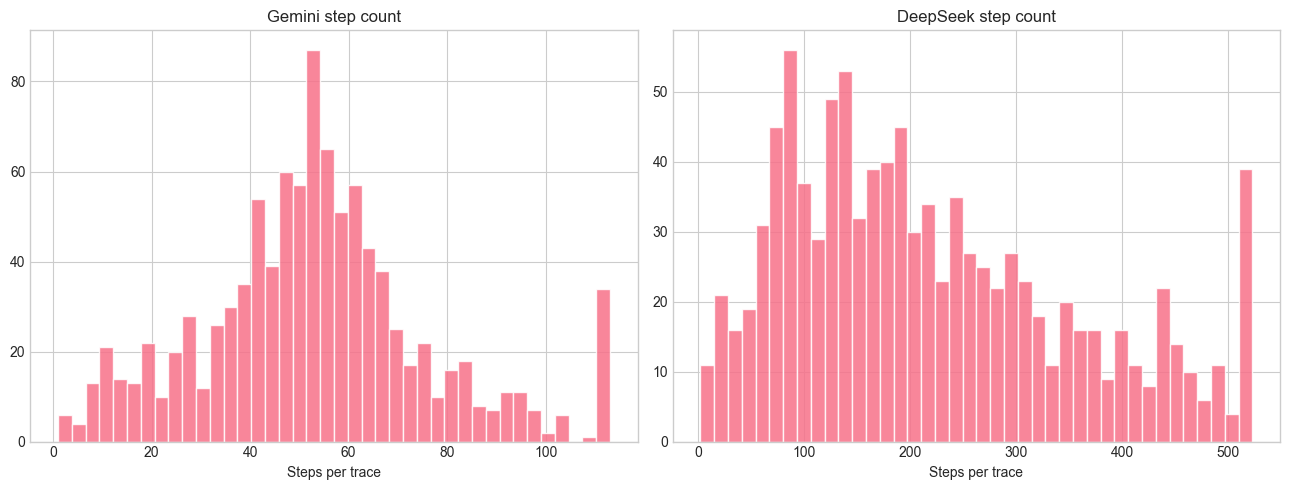

In [6]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
for ax, col, title in zip(
    axes,
    ["gemini_step_count", "deepseek_step_count"],
    ["Gemini step count", "DeepSeek step count"]
):
    clip_val = df[col].quantile(0.97)
    ax.hist(df[col].clip(upper=clip_val), bins=40, edgecolor="white", alpha=0.85)
    ax.set_title(title); ax.set_xlabel("Steps per trace")
plt.tight_layout(); plt.show()

## 4. Step Classification  (Qwen3-8B, 4-bit)

Steps are classified into one of six cognitive operations:

| Label | Meaning |
|---|---|
| Setup | Problem framing, defining variables, restating givens |
| Computation | Calculations, logical deductions, algebraic steps |
| Verification | Checking work, sanity checks, re-reading the question |
| Backtrack | Recognising errors, revising approach ("wait, that's wrong") |
| Exploration | Brainstorming, expressing uncertainty, considering alternatives |
| Conclusion | Final answer / summary |

Classification is **cached** — the model loads and runs once, results are
saved to `step_classifications.parquet`.

In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

SYSTEM_PROMPT = """You are a reasoning-step classifier for AI research.
Classify the reasoning step below into exactly ONE of these categories:
- Setup        : problem framing, stating givens, defining variables
- Computation  : calculations, algebraic steps, logical deductions
- Verification : checking work, sanity-checking, re-reading the question
- Backtrack    : recognising errors, revising approach ("wait", "actually", "no,")
- Exploration  : brainstorming, expressing uncertainty, considering alternatives
- Conclusion   : final answer statement, summarising the solution

Reply with ONLY the category name — nothing else."""

def load_model():
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    tok = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    mdl = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, quantization_config=bnb, device_map="auto",
        trust_remote_code=True
    )
    mdl.eval()
    return tok, mdl

def classify_batch(steps: list, tok, mdl, batch_size=8) -> list:
    results = []
    for i in range(0, len(steps), batch_size):
        batch = steps[i : i + batch_size]
        prompts = [
            tok.apply_chat_template(
                [{"role": "system", "content": SYSTEM_PROMPT},
                 {"role": "user",   "content": s[:600]}],
                tokenize=False, add_generation_prompt=True
            )
            for s in batch
        ]
        inp = tok(prompts, return_tensors="pt", padding=True,
                  truncation=True, max_length=1024).to(mdl.device)
        with torch.no_grad():
            out = mdl.generate(**inp, max_new_tokens=8,
                               pad_token_id=tok.eos_token_id, do_sample=False)
        in_len = inp["input_ids"].shape[1]
        for j, o in enumerate(out):
            raw = tok.decode(o[in_len:], skip_special_tokens=True).strip()
            label = next((l for l in LABELS if l.lower() in raw.lower()), "Computation")
            results.append(label)
    return results

In [11]:
import re

def parse_numpy_str_array(s):
    if not isinstance(s, str):
        return s
    
    # Extract all quoted tokens, ignoring '...' truncation
    tokens = re.findall(r"'([^']*)'", s)
    return tokens

classified_df['labels'] = classified_df['labels'].apply(parse_numpy_str_array)

# Verify
print(classified_df['labels'].head())
print(f"First row has {len(classified_df['labels'].iloc[0])} labels")

0    [Setup, Computation, Setup, Setup, Backtrack, ...
1    [Computation, Computation, Computation, Setup,...
2    [Setup, Setup, Computation, Conclusion, Setup,...
3    [Setup, Computation, Setup, Computation, Setup...
4    [Setup, Computation, Setup, Computation, Compu...
Name: labels, dtype: object
First row has 53 labels


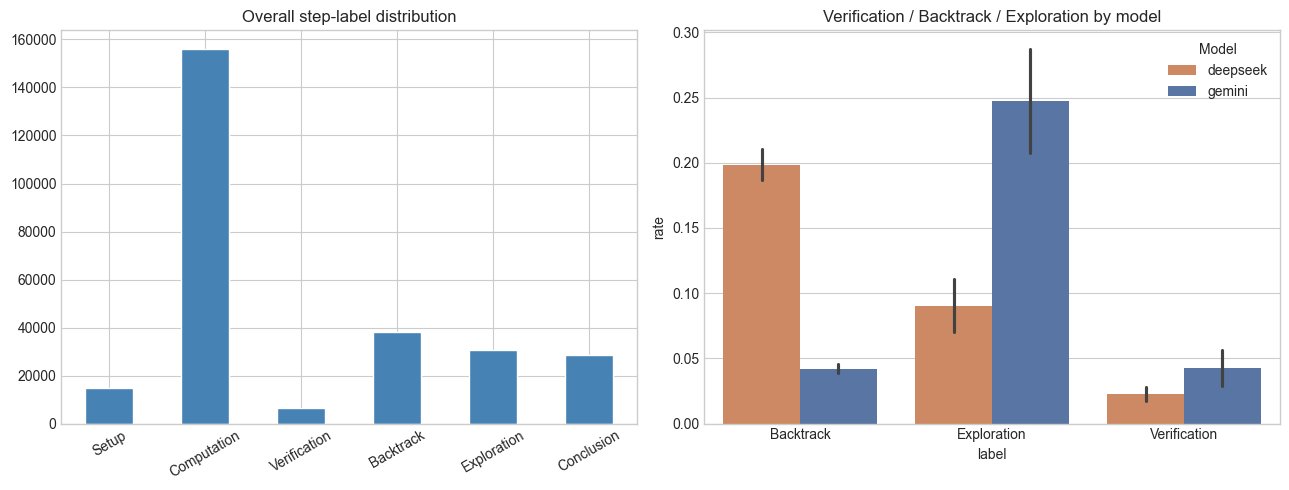

In [12]:
import ast
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean label names: no extra quotes
LABELS = ["Setup", "Computation", "Verification", "Backtrack", "Exploration", "Conclusion"]
LABEL_TO_IDX = {l: i for i, l in enumerate(LABELS)}

def parse_labels(x):
    """Convert a stringified list like '["Setup", "Computation"]' into a Python list."""
    if isinstance(x, list):
        return [str(v).strip().strip('"').strip("'") for v in x]
    if pd.isna(x):
        return []
    if isinstance(x, str):
        s = x.strip()
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(v).strip().strip('"').strip("'") for v in parsed]
        except Exception:
            pass
        # Fallback for messy strings
        return [t.strip().strip('"').strip("'") for t in s.strip("[]").split(",") if t.strip()]
    return []

classified_df = classified_df.copy()
classified_df["labels"] = classified_df["labels"].apply(parse_labels)

# ── Label frequency overview ──
all_labels = [l for seq in classified_df["labels"] for l in seq]
label_counts = Counter(all_labels)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Overall distribution
pd.Series(label_counts).reindex(LABELS, fill_value=0).plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Overall step-label distribution")
axes[0].tick_params(axis="x", rotation=30)

# Per-model per-correctness
rows = []
for _, r in classified_df.iterrows():
    labels = r["labels"]
    c = Counter(labels)
    n = max(len(labels), 1)
    for lbl in LABELS:
        rows.append({
            "model": r["model"],
            "correct": r["correct"],
            "label": lbl,
            "rate": c.get(lbl, 0) / n
        })

rate_df = pd.DataFrame(rows).groupby(["model", "correct", "label"], as_index=False)["rate"].mean()

g = rate_df[rate_df["label"].isin(["Verification", "Backtrack", "Exploration"])]
sns.barplot(
    data=g,
    x="label",
    y="rate",
    hue="model",
    ax=axes[1],
    palette={"gemini": "#4C72B0", "deepseek": "#DD8452"},
)
axes[1].set_title("Verification / Backtrack / Exploration by model")
axes[1].legend(title="Model")

plt.tight_layout()
plt.show()

## 5. Transition Matrix Analysis

In [13]:
def raw_transition_matrix(sequences: list) -> np.ndarray:
    n = len(LABELS)
    mat = np.zeros((n, n), dtype=float)
    for seq in sequences:
        for a, b in zip(seq[:-1], seq[1:]):
            i, j = LABEL_TO_IDX.get(a), LABEL_TO_IDX.get(b)
            if i is not None and j is not None:
                mat[i, j] += 1
    return mat

def normalise(mat: np.ndarray) -> np.ndarray:
    s = mat.sum(axis=1, keepdims=True)
    s[s == 0] = 1
    return mat / s

def get_seqs(model, correct):
    mask = (classified_df["model"] == model) & (classified_df["correct"] == correct)
    return classified_df.loc[mask, "labels"].tolist()

splits = {
    ("gemini",   1): get_seqs("gemini",   1),
    ("gemini",   0): get_seqs("gemini",   0),
    ("deepseek", 1): get_seqs("deepseek", 1),
    ("deepseek", 0): get_seqs("deepseek", 0),
}
raw_mats  = {k: raw_transition_matrix(v) for k, v in splits.items()}
norm_mats = {k: normalise(m)             for k, m in raw_mats.items()}

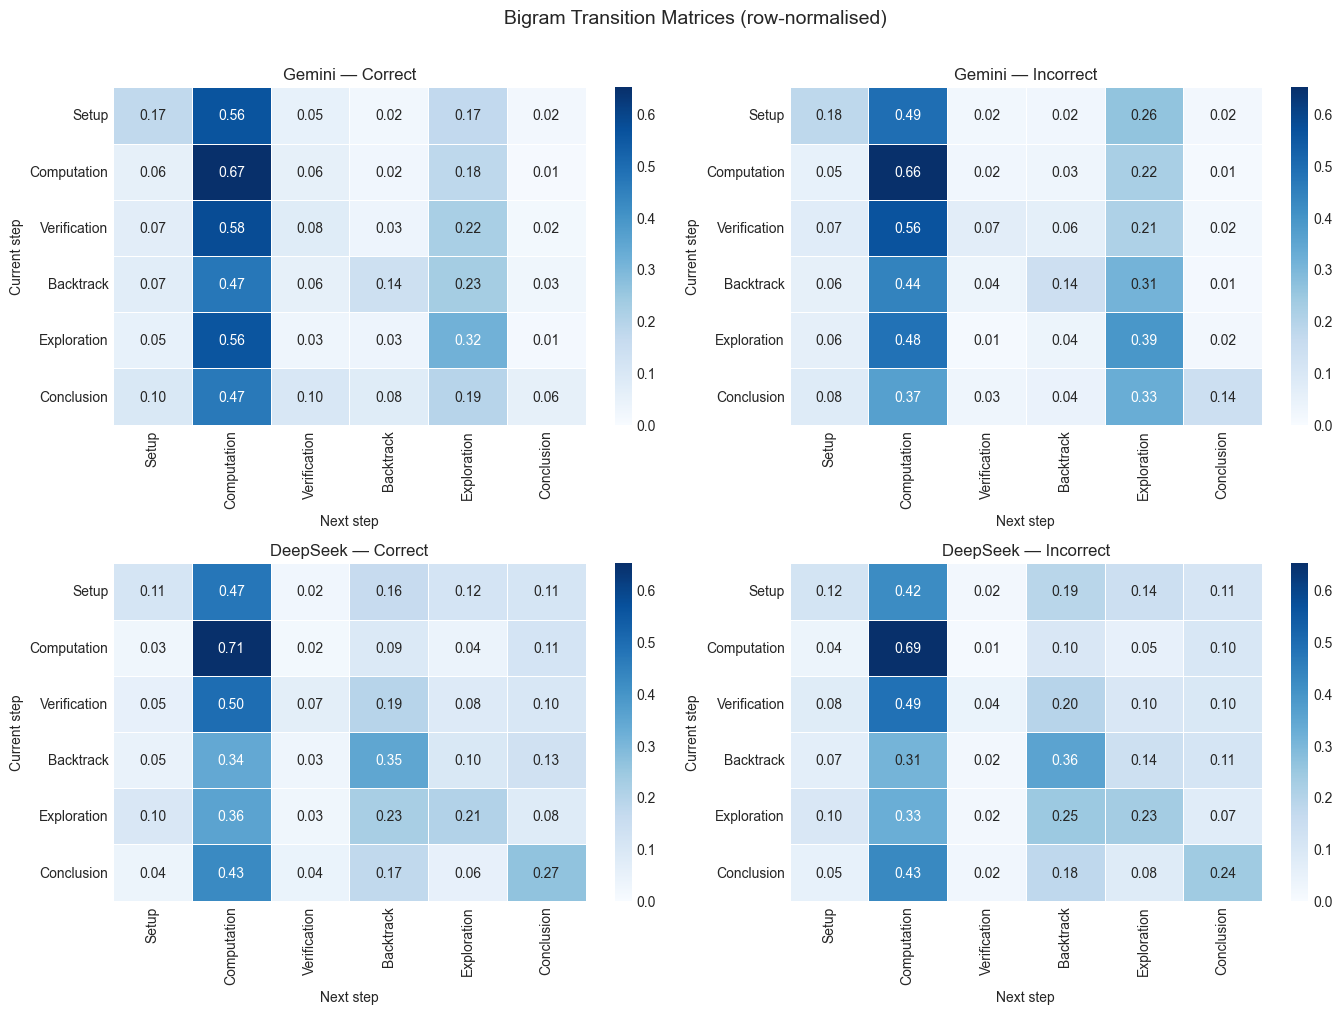

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_keys  = [("gemini",1), ("gemini",0), ("deepseek",1), ("deepseek",0)]
plot_titles= ["Gemini — Correct","Gemini — Incorrect","DeepSeek — Correct","DeepSeek — Incorrect"]

for ax, key, title in zip(axes.flat, plot_keys, plot_titles):
    sns.heatmap(norm_mats[key], xticklabels=LABELS, yticklabels=LABELS,
                annot=True, fmt=".2f", cmap="Blues", ax=ax, vmin=0, vmax=0.65,
                linewidths=0.4)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Next step"); ax.set_ylabel("Current step")

plt.suptitle("Bigram Transition Matrices (row-normalised)", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

In [15]:
from scipy.stats import chi2_contingency

def test_transition_difference(raw1: np.ndarray, raw2: np.ndarray) -> pd.DataFrame:
    """Row-wise chi-square test between two raw count matrices."""
    rows = []
    for i, from_lbl in enumerate(LABELS):
        r1, r2 = raw1[i], raw2[i]
        if r1.sum() < 5 or r2.sum() < 5:
            continue
        try:
            chi2, p, _, _ = chi2_contingency(np.array([r1, r2]) + 0.5)
            rows.append({"from": from_lbl, "chi2": round(chi2, 2), "p_raw": round(p, 5)})
        except Exception:
            pass
    out = pd.DataFrame(rows)
    if not out.empty:
        _, out["p_fdr"], _, _ = multipletests(out["p_raw"], method="fdr_bh")
        out["p_fdr"] = out["p_fdr"].round(5)
    return out

print("=== Correct vs Incorrect — GEMINI ===")
print(test_transition_difference(raw_mats[("gemini",1)], raw_mats[("gemini",0)]).to_string(index=False))
print("\n=== Correct vs Incorrect — DeepSeek ===")
print(test_transition_difference(raw_mats[("deepseek",1)], raw_mats[("deepseek",0)]).to_string(index=False))

=== Correct vs Incorrect — GEMINI ===
        from   chi2   p_raw   p_fdr
       Setup  73.81 0.00000 0.00000
 Computation 300.34 0.00000 0.00000
Verification   8.61 0.12564 0.12564
   Backtrack  21.79 0.00057 0.00068
 Exploration 131.85 0.00000 0.00000
  Conclusion  43.91 0.00000 0.00000

=== Correct vs Incorrect — DeepSeek ===
        from   chi2   p_raw   p_fdr
       Setup  44.83 0.00000 0.00000
 Computation 321.70 0.00000 0.00000
Verification  23.81 0.00024 0.00024
   Backtrack 288.84 0.00000 0.00000
 Exploration  51.01 0.00000 0.00000
  Conclusion 184.31 0.00000 0.00000


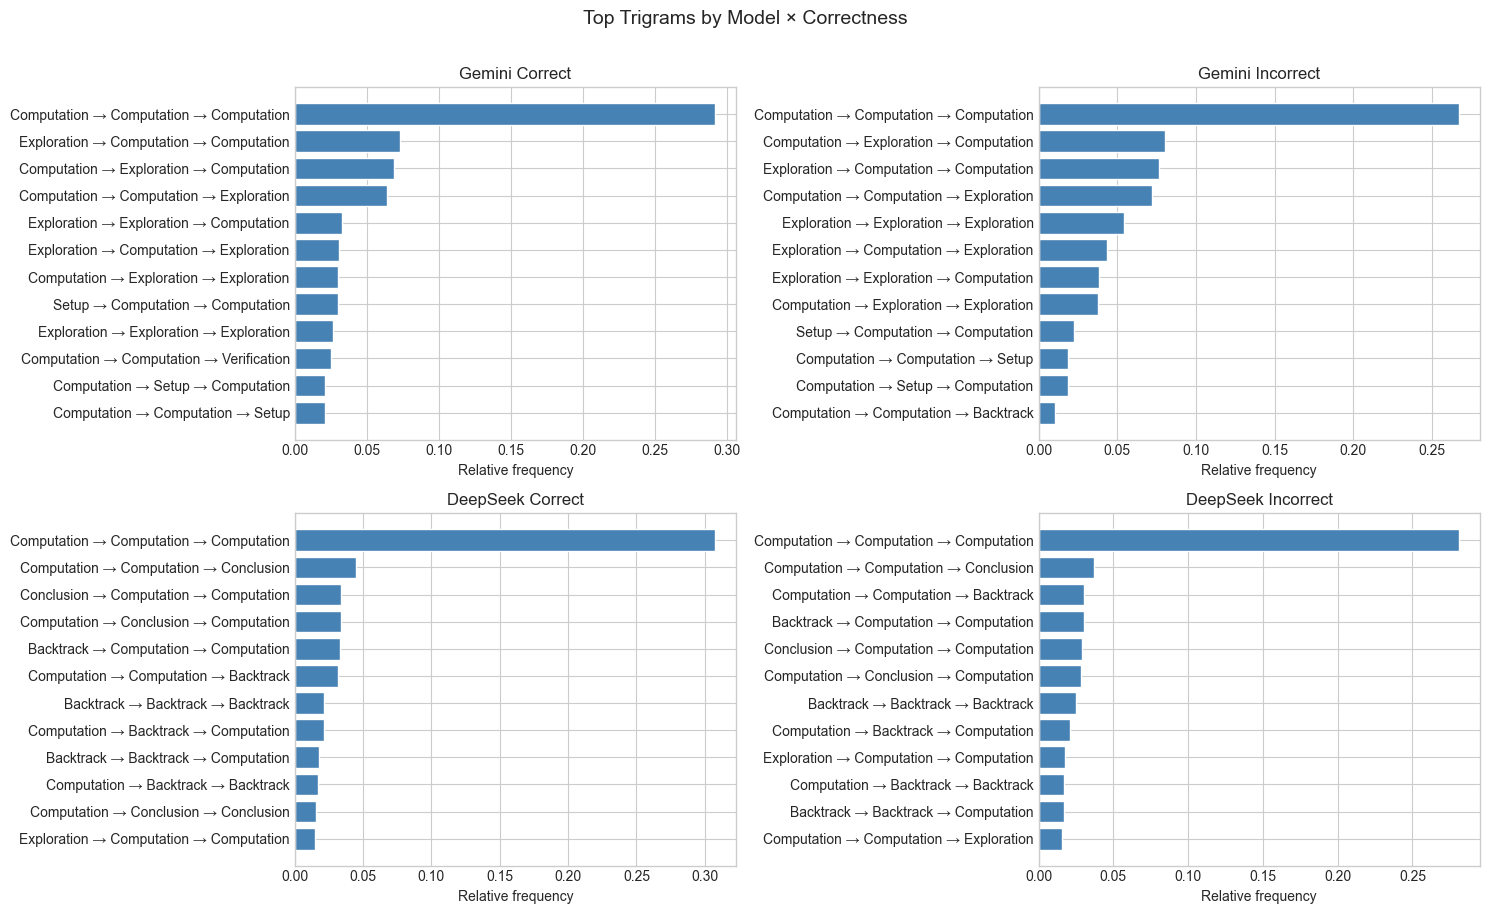

In [16]:
# ── n-gram frequency comparison ─────────────────────────────────────────────
def ngram_freq(sequences: list, n: int = 3, top_k: int = 12) -> pd.Series:
    counts = Counter()
    for seq in sequences:
        for i in range(len(seq) - n + 1):
            counts[" → ".join(seq[i:i+n])] += 1
    total = sum(counts.values()) or 1
    return pd.Series({k: v/total for k,v in counts.most_common(top_k)})

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, (mdl, correct), title in zip(
    axes.flat, splits.keys(),
    ["Gemini Correct","Gemini Incorrect","DeepSeek Correct","DeepSeek Incorrect"]
):
    freqs = ngram_freq(splits[(mdl, correct)], n=3)
    ax.barh(freqs.index[::-1], freqs.values[::-1], color="steelblue", edgecolor="white")
    ax.set_title(title); ax.set_xlabel("Relative frequency")
plt.suptitle("Top Trigrams by Model × Correctness", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

## 6. Correctness Prediction

Three models are compared:

| Model | Features |
|---|---|
| **M1 – BoW** | TF-IDF on full trace te`xt (vocabulary only, no order) |
| **M2 – Structural** | Derived from label sequences only (no lexical content) |
| **M3 – Combined** | M1 + M2 together |

A **shuffling control** tests whether *sequential* structure (step order)
carries signal beyond label frequencies alone.

In [17]:
def structural_features(label_seq: list) -> dict:
    n = max(len(label_seq), 1)
    counts = Counter(label_seq)
    feats = {f"rate_{l}": counts.get(l, 0) / n for l in LABELS}
    feats["n_steps"] = n

    bigs = list(zip(label_seq[:-1], label_seq[1:]))
    nb   = max(len(bigs), 1)
    feats["t_verif_comp"]     = bigs.count(("Verification", "Computation")) / nb
    feats["t_backtrack_loop"] = bigs.count(("Backtrack",    "Backtrack"))    / nb
    feats["t_comp_conclude"]  = bigs.count(("Computation",  "Conclusion"))   / nb
    feats["t_verif_backtrack"]= bigs.count(("Verification", "Backtrack"))    / nb
    feats["t_setup_comp"]     = bigs.count(("Setup",        "Computation"))  / nb

    trigs = list(zip(label_seq[:-2], label_seq[1:-1], label_seq[2:]))
    nt    = max(len(trigs), 1)
    feats["t3_error_correct"] = trigs.count(("Verification","Backtrack","Computation")) / nt

    # Early conclusion flag
    if "Conclusion" in label_seq:
        last_c = max(i for i, l in enumerate(label_seq) if l == "Conclusion")
        feats["early_conclusion"] = int(last_c < 0.8 * n)
    else:
        feats["early_conclusion"] = 0

    return feats

feat_rows = []
for _, row in classified_df.iterrows():
    f = structural_features(row["labels"])
    f["correct"] = row["correct"]
    f["model"]   = row["model"]
    f["domain"]  = row["domain"]
    f["question_id"] = row["question_id"]
    feat_rows.append(f)

feat_df = pd.DataFrame(feat_rows)
FEAT_COLS = [c for c in feat_df.columns if c not in ["correct","model","domain","question_id"]]
print(f"Structural feature count: {len(FEAT_COLS)}")
print(feat_df[FEAT_COLS].describe().round(3))

Structural feature count: 14
       rate_Setup  rate_Computation  rate_Verification  rate_Backtrack  \
count    2000.000          2000.000           2000.000        2000.000   
mean        0.070             0.531              0.034           0.118   
std         0.073             0.205              0.042           0.122   
min         0.000             0.000              0.000           0.000   
25%         0.028             0.445              0.008           0.019   
50%         0.053             0.576              0.023           0.091   
75%         0.090             0.670              0.045           0.181   
max         1.000             0.950              0.750           1.000   

       rate_Exploration  rate_Conclusion   n_steps  t_verif_comp  \
count          2000.000         2000.000  2000.000      2000.000   
mean              0.165            0.082   137.504         0.016   
std               0.154            0.084   131.049         0.024   
min               0.000         

In [18]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer

# ── Attach original traces for BoW ──────────────────────────────────────────
trace_map = {}
for idx, row in df.iterrows():
    trace_map[(idx, "gemini")]   = row["gemini_thinking_trajectory"]   or ""
    trace_map[(idx, "deepseek")] = row["deepseek_thinking_trajectory"] or ""

feat_df["full_trace"] = feat_df.apply(
    lambda r: trace_map.get((r["question_id"], r["model"]), ""), axis=1
)

y = feat_df["correct"].values
X_struct = feat_df[FEAT_COLS].values
X_text   = feat_df["full_trace"].values

# Create combined features
X_combined = feat_df[["full_trace"] + FEAT_COLS].copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

def cv_eval(pipe, X, y, name):
    scores = cross_validate(pipe, X, y, cv=cv,
                            scoring=["roc_auc","accuracy"], n_jobs=-1)
    print(f"  {name:<32}  AUC {scores['test_roc_auc'].mean():.3f}±{scores['test_roc_auc'].std():.3f}"
          f"   Acc {scores['test_accuracy'].mean():.3f}±{scores['test_accuracy'].std():.3f}")
    return scores

# Model 1: BoW only
m1 = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ("clf",   LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
])

# Model 2: Structural features only
m2 = Pipeline([
    ("sc",   StandardScaler()),
    ("clf",  LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
])

# Model 3: Combined (text + structural features)
# Helper to extract text column
def get_text_column(X):
    return X["full_trace"].values

# Helper to extract structural columns
def get_struct_columns(X):
    return X[FEAT_COLS].values

m3 = Pipeline([
    ("features", FeatureUnion([
        ("text", Pipeline([
            ("selector", FunctionTransformer(get_text_column, validate=False)),
            ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2)))
        ])),
        ("struct", Pipeline([
            ("selector", FunctionTransformer(get_struct_columns, validate=False)),
            ("scaler", StandardScaler())
        ]))
    ])),
    ("clf", LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
])

print("=== 5-fold Cross-Validation ===")
s1 = cv_eval(m1, X_text,     y, "M1 — BoW TF-IDF")
s2 = cv_eval(m2, X_struct,   y, "M2 — Structural features")
s3 = cv_eval(m3, X_combined, y, "M3 — Combined (BoW + Struct)")

# Optional: Statistical comparison
print("\n=== AUC Improvements ===")
print(f"M3 vs M1: {s3['test_roc_auc'].mean() - s1['test_roc_auc'].mean():+.3f}")
print(f"M3 vs M2: {s3['test_roc_auc'].mean() - s2['test_roc_auc'].mean():+.3f}")

=== 5-fold Cross-Validation ===
  M1 — BoW TF-IDF                   AUC 0.770±0.011   Acc 0.699±0.012
  M2 — Structural features          AUC 0.725±0.030   Acc 0.694±0.025
  M3 — Combined (BoW + Struct)      AUC 0.796±0.014   Acc 0.726±0.013

=== AUC Improvements ===
M3 vs M1: +0.026
M3 vs M2: +0.071


In [19]:
# ── Shuffling control ────────────────────────────────────────────────────────
def shuffle_seq(seq):
    s = seq[:]
    np.random.shuffle(s)
    return s

shuffled_feats = [structural_features(shuffle_seq(row["labels"])) for _, row in classified_df.iterrows()]
X_shuffled = pd.DataFrame(shuffled_feats)[FEAT_COLS].values

print("\n=== Shuffling Control ===")
s2_shuf = cv_eval(m2, X_shuffled, y, "M2 (labels shuffled — control)")

delta = s2["test_accuracy"].mean() - s2_shuf["test_accuracy"].mean()
crit  = "✓ MET" if delta >= 0.10 else "✗ NOT MET"
print(f"\nAccuracy drop from shuffling: {delta:+.3f}  (criterion ≥ 0.10) → {crit}")


=== Shuffling Control ===
  M2 (labels shuffled — control)    AUC 0.729±0.022   Acc 0.700±0.021

Accuracy drop from shuffling: -0.006  (criterion ≥ 0.10) → ✗ NOT MET


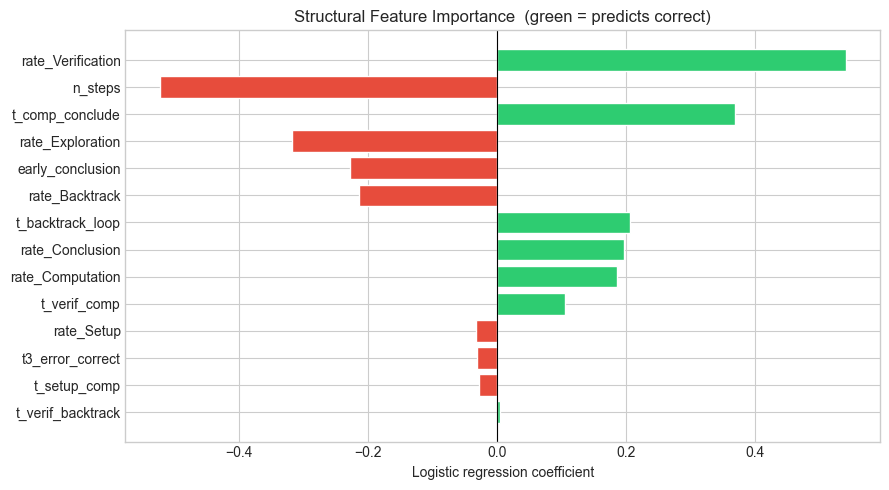

In [20]:
# ── Feature importance ───────────────────────────────────────────────────────
m2.fit(X_struct, y)
coef = m2.named_steps["clf"].coef_[0]
imp  = pd.Series(coef, index=FEAT_COLS).sort_values(key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in imp.values]
ax.barh(imp.index[::-1], imp.values[::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Structural Feature Importance  (green = predicts correct)")
ax.set_xlabel("Logistic regression coefficient")
plt.tight_layout(); plt.show()

## 7. Model Comparison — Gemini vs DeepSeek

Two strategies to control for the capability gap:

1. **Within-correctness comparison** — compare correct Gemini to correct DeepSeek traces (and
   incorrect to incorrect), so capability differences don't confound the structural findings.
2. **Logistic regression with interaction terms** — lets structural features predict correctness
   differently per model.

In [21]:
import statsmodels.formula.api as smf

key_feats = ["rate_Verification","rate_Backtrack","rate_Exploration","n_steps",
             "t_verif_comp","t_backtrack_loop","t3_error_correct"]

print("=== Within-correctness structural comparison (Mann-Whitney U) ===\n")
for correct_val, label in [(1,"Correct"), (0,"Incorrect")]:
    print(f"  {label} traces:")
    g = feat_df[(feat_df["model"]=="gemini")   & (feat_df["correct"]==correct_val)]
    d = feat_df[(feat_df["model"]=="deepseek") & (feat_df["correct"]==correct_val)]
    rows = []
    for f in key_feats:
        stat, p = stats.mannwhitneyu(g[f].dropna(), d[f].dropna(), alternative="two-sided")
        sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
        rows.append({"feature": f,
                     "Gemini_mean": g[f].mean(), "DeepSeek_mean": d[f].mean(),
                     "p": round(p,4), "sig": sig})
    print(pd.DataFrame(rows).to_string(index=False), "\n")

=== Within-correctness structural comparison (Mann-Whitney U) ===

  Correct traces:
          feature  Gemini_mean  DeepSeek_mean   p sig
rate_Verification     0.056278       0.027816 0.0 ***
   rate_Backtrack     0.038416       0.186406 0.0 ***
 rate_Exploration     0.207267       0.070339 0.0 ***
          n_steps    49.011194     192.614286 0.0 ***
     t_verif_comp     0.028864       0.012400 0.0 ***
 t_backtrack_loop     0.006673       0.073048 0.0 ***
 t3_error_correct     0.000975       0.001672 0.0 *** 

  Incorrect traces:
          feature  Gemini_mean  DeepSeek_mean      p sig
rate_Verification     0.028454       0.017671 0.6869  ns
   rate_Backtrack     0.045330       0.210372 0.0000 ***
 rate_Exploration     0.287108       0.110727 0.0000 ***
          n_steps    59.870690     269.216216 0.0000 ***
     t_verif_comp     0.013240       0.007663 0.0615  ns
 t_backtrack_loop     0.005715       0.083034 0.0000 ***
 t3_error_correct     0.000898       0.000991 0.0000 *** 



In [22]:
# ── Logistic regression with interaction terms ──────────────────────────────
feat_df["model_bin"] = (feat_df["model"] == "deepseek").astype(int)
formula = (
    "correct ~ rate_Verification + rate_Backtrack + t_verif_comp + "
    "t_backtrack_loop + n_steps + model_bin + "
    "model_bin:rate_Verification + model_bin:rate_Backtrack"
)
lm = smf.logit(formula, data=feat_df).fit(disp=0)
print(lm.summary2().tables[1][["Coef.","P>|z|","[0.025","0.975]"]].round(4))

                               Coef.   P>|z|   [0.025   0.975]
Intercept                    -0.0621  0.5834  -0.2841   0.1599
rate_Verification             9.4346  0.0000   5.0256  13.8436
rate_Backtrack               -4.0770  0.0010  -6.5046  -1.6494
t_verif_comp                 14.1872  0.0001   7.0726  21.3017
t_backtrack_loop              9.3640  0.0000   5.3997  13.3283
n_steps                      -0.0063  0.0000  -0.0075  -0.0051
model_bin                     3.1494  0.0000   2.5597   3.7392
model_bin:rate_Verification   3.8184  0.3837  -4.7735  12.4104
model_bin:rate_Backtrack     -7.3193  0.0000 -10.2618  -4.3767


## 8. Domain-Specific Analysis

In [23]:
import pandas as pd

# Create a mapping from the original df using the index
# Reset index to make it a column, then select index and cot_type
cot_type_map = df.reset_index()[['index', 'cot_type']].rename(columns={'index': 'question_id'})

# Merge cot_type into classified_df based on question_id (which corresponds to df's index)
classified_df = classified_df.merge(
    cot_type_map, 
    on='question_id', 
    how='left'
)

# Verify the merge
print("Columns in classified_df after merge:")
print(classified_df.columns.tolist())
print("\nSample of merged data:")
print(classified_df[['question_id', 'model', 'correct', 'domain', 'cot_type']].head())

# Check for any missing cot_type values
missing_cot_type = classified_df['cot_type'].isna().sum()
print(f"\nRows with missing cot_type: {missing_cot_type}")

# Create broad_domain column using cot_type
def broad_domain_from_cot(cot):
    if not isinstance(cot, str): 
        return "Other"
    cot = cot.lower()
    if any(k in cot for k in ["math", "calculus", "algebra", "geometry", "olympiad", "combinatorics", "number theory"]):
        return "Mathematics"
    if any(k in cot for k in ["physics", "chemistry", "biology", "ecology", "biochem", "genetics", "science"]):
        return "Sciences"
    if any(k in cot for k in ["history", "literature", "philosophy", "art", "social", "politics", "economics", "law"]):
        return "Humanities"
    if any(k in cot for k in ["computer", "code", "algorithm", "programming", "cs"]):
        return "Computer Science"
    return "Other"

classified_df["broad_domain"] = classified_df["cot_type"].apply(broad_domain_from_cot)
print("\nBroad domain distribution:")
print(classified_df["broad_domain"].value_counts())

Columns in classified_df after merge:
['question_id', 'model', 'labels', 'correct', 'domain', 'n_steps', 'cot_type']

Sample of merged data:
   question_id     model  correct                           domain cot_type
0            0    gemini        1            qq8933/AIME_1983_2024     math
1            0  deepseek        1            qq8933/AIME_1983_2024     math
2            1    gemini        0  AI-MO/NuminaMath-CoT/aops_forum     math
3            1  deepseek        0  AI-MO/NuminaMath-CoT/aops_forum     math
4            2    gemini        1            qq8933/AIME_1983_2024     math

Rows with missing cot_type: 0

Broad domain distribution:
broad_domain
Mathematics    1754
Sciences        216
Other            30
Name: count, dtype: int64


In [24]:
from scipy.stats import f_oneway, kruskal

# Kruskal-Wallis for each structural feature ~ broad domain
print("=== Kruskal-Wallis: structural features ~ domain ===\n")
feat_df["broad_domain"] = classified_df["cot_type"].apply(broad_domain_from_cot)
domain_groups = feat_df["broad_domain"].unique()
for f in ["rate_Verification","rate_Computation","rate_Exploration","rate_Backtrack"]:
    groups = [feat_df[feat_df["broad_domain"]==d][f].values
              for d in domain_groups if (feat_df["broad_domain"]==d).sum() > 5]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        print(f"  {f:<25}  H={stat:.1f}  p={p:.4f}")

# Domain means table
dom_mean = feat_df.groupby("broad_domain")[
    ["rate_Verification","rate_Computation","rate_Exploration","rate_Backtrack","correct"]
].mean().round(3)
print("\n", dom_mean)

=== Kruskal-Wallis: structural features ~ domain ===

  rate_Verification          H=0.5  p=0.7797
  rate_Computation           H=49.9  p=0.0000
  rate_Exploration           H=45.9  p=0.0000
  rate_Backtrack             H=57.5  p=0.0000

               rate_Verification  rate_Computation  rate_Exploration  \
broad_domain                                                          
Mathematics               0.033             0.542             0.164   
Other                     0.047             0.173             0.411   
Sciences                  0.037             0.489             0.135   

              rate_Backtrack  correct  
broad_domain                           
Mathematics            0.108    0.589  
Other                  0.269    0.067  
Sciences               0.182    0.606  


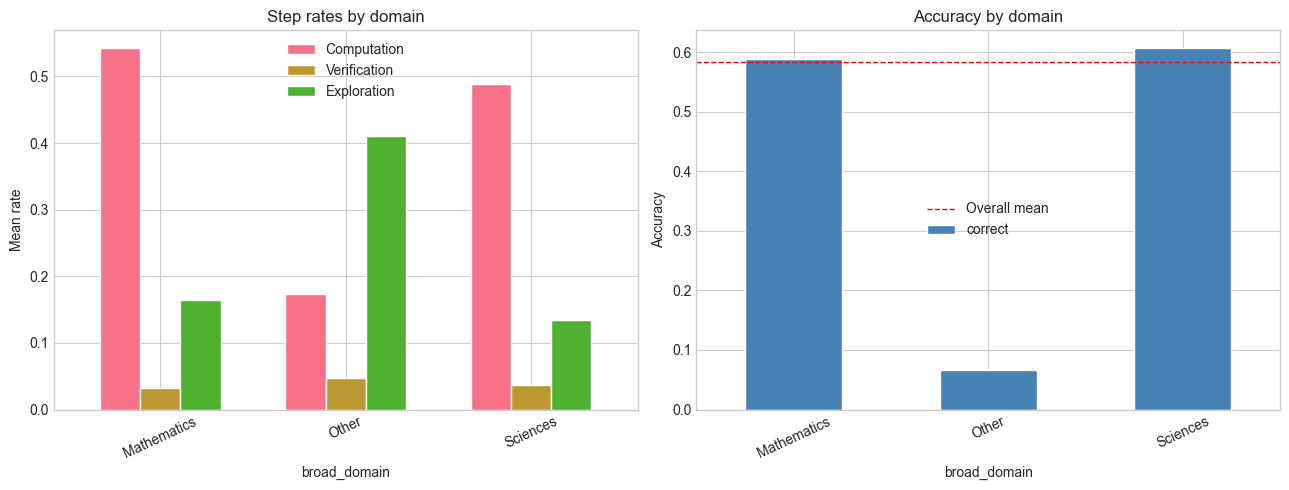

In [25]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

dom_mean[["rate_Computation","rate_Verification","rate_Exploration"]].plot(
    kind="bar", ax=axes[0], width=0.65, edgecolor="white"
)
axes[0].set_title("Step rates by domain"); axes[0].tick_params(axis="x", rotation=25)
axes[0].set_ylabel("Mean rate"); axes[0].legend(["Computation","Verification","Exploration"])

dom_mean["correct"].plot(kind="bar", ax=axes[1], color="steelblue", width=0.5, edgecolor="white")
axes[1].axhline(feat_df["correct"].mean(), color="red", ls="--", lw=1, label="Overall mean")
axes[1].set_title("Accuracy by domain"); axes[1].tick_params(axis="x", rotation=25)
axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.tight_layout(); plt.show()

## 9. Hidden Markov Models

HMMs treat each trace as a sequence of *observed* step labels and infer
**latent reasoning states** (e.g. "confident solving" vs "uncertain
exploration"). We fit one HMM per (model × correctness) split and inspect
emission probabilities to characterise each hidden state.

In [26]:
N_HMM_STATES = 4

def prep_hmm(sequences):
    enc, lengths = [], []
    for seq in sequences:
        e = [LABEL_TO_IDX[l] for l in seq if l in LABEL_TO_IDX]
        if len(e) >= 3:
            enc.extend(e); lengths.append(len(e))
    return np.array(enc).reshape(-1, 1), lengths

def fit_hmm(sequences, n_states=N_HMM_STATES):
    X, lengths = prep_hmm(sequences)
    if len(lengths) < 10: return None
    hmm = CategoricalHMM(n_components=n_states, n_iter=150,
                         random_state=RANDOM_SEED, n_features=len(LABELS))
    hmm.n_features = len(LABELS)
    try:
        hmm.fit(X, lengths); return hmm
    except Exception as e:
        print(f"  HMM fit failed: {e}"); return None

hmm_models = {}
for key, seqs in splits.items():
    h = fit_hmm(seqs)
    if h: hmm_models[key] = h
    print(f"  {key[0]} {'correct' if key[1] else 'incorrect'}: {'OK' if h else 'FAILED'} ({len(seqs)} traces)")

  gemini correct: OK (536 traces)
  gemini incorrect: OK (464 traces)
  deepseek correct: OK (630 traces)
  deepseek incorrect: OK (370 traces)


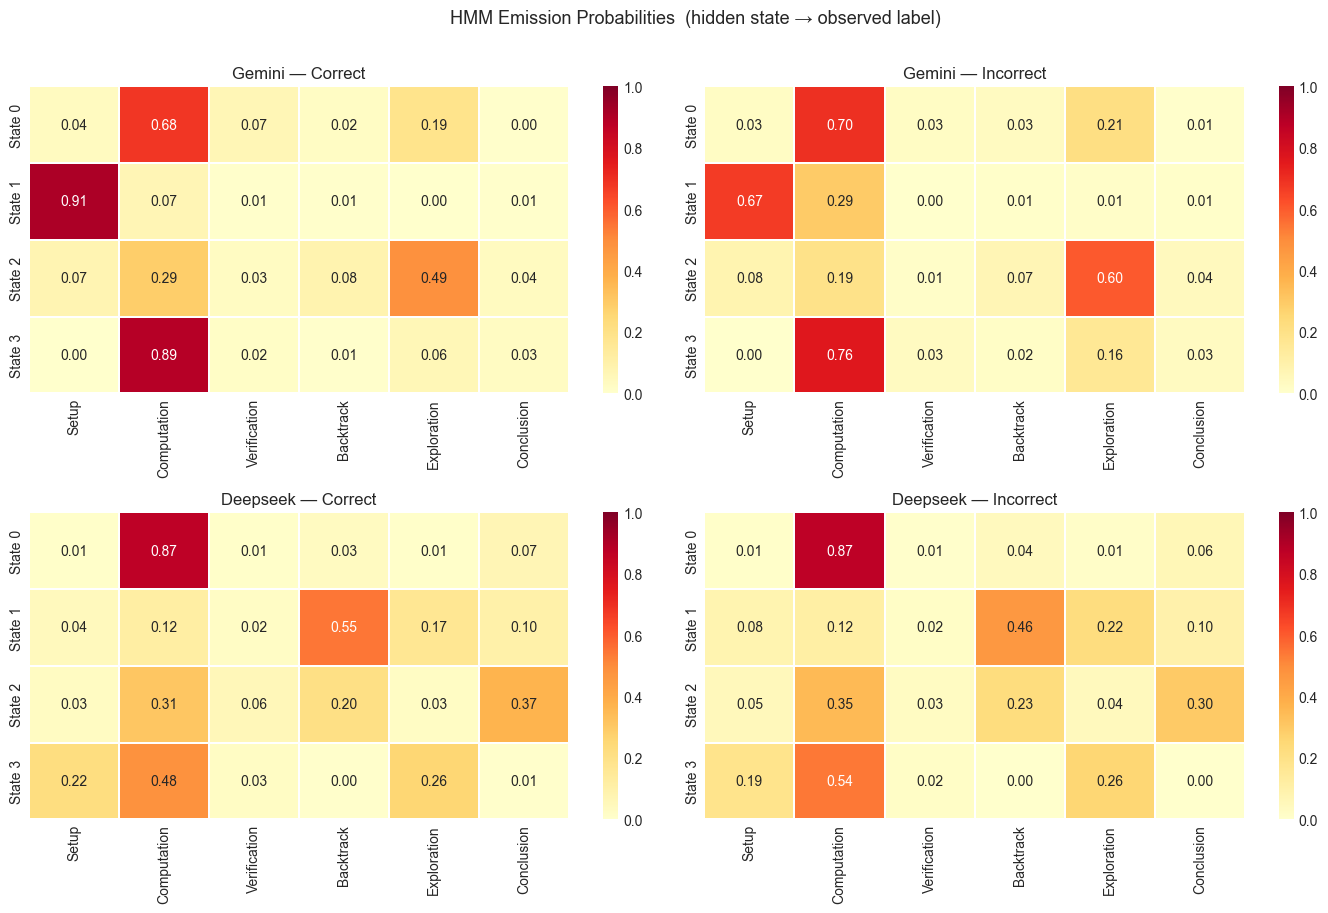

In [27]:
if hmm_models:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for ax, (key, hmm) in zip(axes.flat, hmm_models.items()):
        sns.heatmap(hmm.emissionprob_, xticklabels=LABELS,
                    yticklabels=[f"State {i}" for i in range(N_HMM_STATES)],
                    annot=True, fmt=".2f", cmap="YlOrRd", ax=ax, vmin=0, vmax=1,
                    linewidths=0.3)
        ax.set_title(f'{key[0].capitalize()} — {"Correct" if key[1] else "Incorrect"}')
    plt.suptitle("HMM Emission Probabilities  (hidden state → observed label)", fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

In [28]:
# ── Cross-score: do correct-HMMs rank incorrect traces lower? ──────────────
def score_seqs(hmm_model, sequences):
    out = []
    for seq in sequences:
        X, lengths = prep_hmm([seq])
        if lengths:
            try: out.append(hmm_model.score(X, lengths) / lengths[0])
            except: pass
    return np.array(out)

for mdl in ["gemini", "deepseek"]:
    if (mdl,1) not in hmm_models or (mdl,0) not in hmm_models: continue
    h = hmm_models[(mdl, 1)]                        # correct-HMM
    sc_corr  = score_seqs(h, splits[(mdl, 1)][:150])
    sc_incorr= score_seqs(h, splits[(mdl, 0)][:150])
    stat, p  = stats.mannwhitneyu(sc_corr, sc_incorr, alternative="greater")
    print(f"{mdl}  correct-HMM log-lik/step: correct={sc_corr.mean():.3f}  "
          f"incorrect={sc_incorr.mean():.3f}  p={p:.4f}")

gemini  correct-HMM log-lik/step: correct=-1.138  incorrect=-1.185  p=0.0607
deepseek  correct-HMM log-lik/step: correct=-1.227  incorrect=-1.327  p=0.0003


## 10. Sequential Pattern Mining (PrefixSpan / FP-Growth)

We encode each trace as a *set* of n-gram patterns and apply FP-Growth
to find frequent reasoning sequences. Patterns are then compared across
correct vs incorrect traces to identify structural signatures of success
and failure.

In [33]:
from collections import defaultdict
from typing import Dict, List, Optional, Sequence, Tuple
import numpy as np
import pandas as pd

EPS = 1e-9

# ── PrefixSpan core ──────────────────────────────────────────────────────────

def _project_sequence(seq, pattern):
    """Return index after last matched element, or None if pattern not found."""
    if not pattern:
        return 0
    start = 0
    for token in pattern:
        for idx in range(start, len(seq)):
            if seq[idx] == token:
                start = idx + 1
                break
        else:
            return None
    return start


def _candidate_counts(sequences, pattern, max_gap=None):
    counts = defaultdict(int)
    for seq in sequences:
        start = _project_sequence(seq, pattern)
        if start is None or start >= len(seq):
            continue
        end = len(seq) if max_gap is None else min(len(seq), start + max_gap)
        seen = set()
        for token in seq[start:end]:
            if token not in seen:
                counts[token] += 1
                seen.add(token)
    return counts


def prefixspan_mine(sequences, min_support=0.06, max_pattern_len=5, max_gap=None):
    """Mine frequent sequential patterns via PrefixSpan recursion."""
    seqs = [tuple(s) for s in sequences if s]
    if not seqs:
        return pd.DataFrame(columns=['support', 'support_count', 'pattern'])

    n = len(seqs)
    min_count = max(1, int(np.ceil(min_support * n)))
    records = []

    def recurse(prefix):
        if len(prefix) >= max_pattern_len:
            return
        for token, cnt in sorted(_candidate_counts(seqs, prefix, max_gap).items()):
            if cnt < min_count:
                continue
            new_prefix = prefix + (token,)
            records.append({
                'support':       cnt / n,
                'support_count': cnt,
                'pattern':       ' → '.join(new_prefix),
            })
            recurse(new_prefix)

    recurse(())

    if not records:
        return pd.DataFrame(columns=['support', 'support_count', 'pattern'])

    return (
        pd.DataFrame(records)
        .sort_values(['support', 'support_count', 'pattern'],
                     ascending=[False, False, True])
        .reset_index(drop=True)
    )


# ── Mine all four splits with auto-fallback support ──────────────────────────

def mine_split(seqs, base_support=0.06, max_pattern_len=5):
    """Mine one split, lowering min_support automatically if needed."""
    fallbacks = list(dict.fromkeys([base_support, 0.03, 0.01, 0.005]))
    for sup in fallbacks:
        result = prefixspan_mine(seqs, min_support=sup, max_pattern_len=max_pattern_len)
        if not result.empty:
            if sup != base_support:
                print(f'    ↳ min_support auto-lowered to {sup}')
            return result
    return pd.DataFrame(columns=['support', 'support_count', 'pattern'])


print('Mining sequential patterns …')
pattern_results = {}

for (mdl, correct), seqs in splits.items():
    # Guard: keep only proper list sequences of length >= 2
    clean_seqs = [s for s in seqs if isinstance(s, list) and len(s) >= 2]
    key = f"{mdl}_{'C' if correct else 'I'}"
    result = mine_split(clean_seqs)
    if result.empty:
        pattern_results[key] = pd.Series(dtype=float)
        print(f'  {key}: 0 patterns found (split size={len(clean_seqs)})')
    else:
        pattern_results[key] = result.set_index('pattern')['support']
        print(f'  {key}: {len(result)} patterns found')


Mining sequential patterns …
  gemini_C: 5147 patterns found
  gemini_I: 5678 patterns found
  deepseek_C: 9330 patterns found
  deepseek_I: 9330 patterns found


=== Patterns enriched in CORRECT vs INCORRECT traces ===

--- GEMINI: Enriched in CORRECT ---
                                                                         correct  incorrect  ratio
pattern                                                                                           
Exploration → Setup → Verification → Verification → Verification           0.224      0.063  3.567
Setup → Verification → Verification → Verification → Verification          0.241      0.069  3.475
Verification → Verification → Verification → Computation → Verification    0.235      0.074  3.194
Computation → Verification → Verification → Verification → Verification    0.244      0.078  3.137
Verification → Verification → Verification → Verification → Computation    0.220      0.071  3.082
Verification → Verification → Verification → Verification                  0.246      0.080  3.075

--- GEMINI: Enriched in INCORRECT ---
                                                              correct  inco

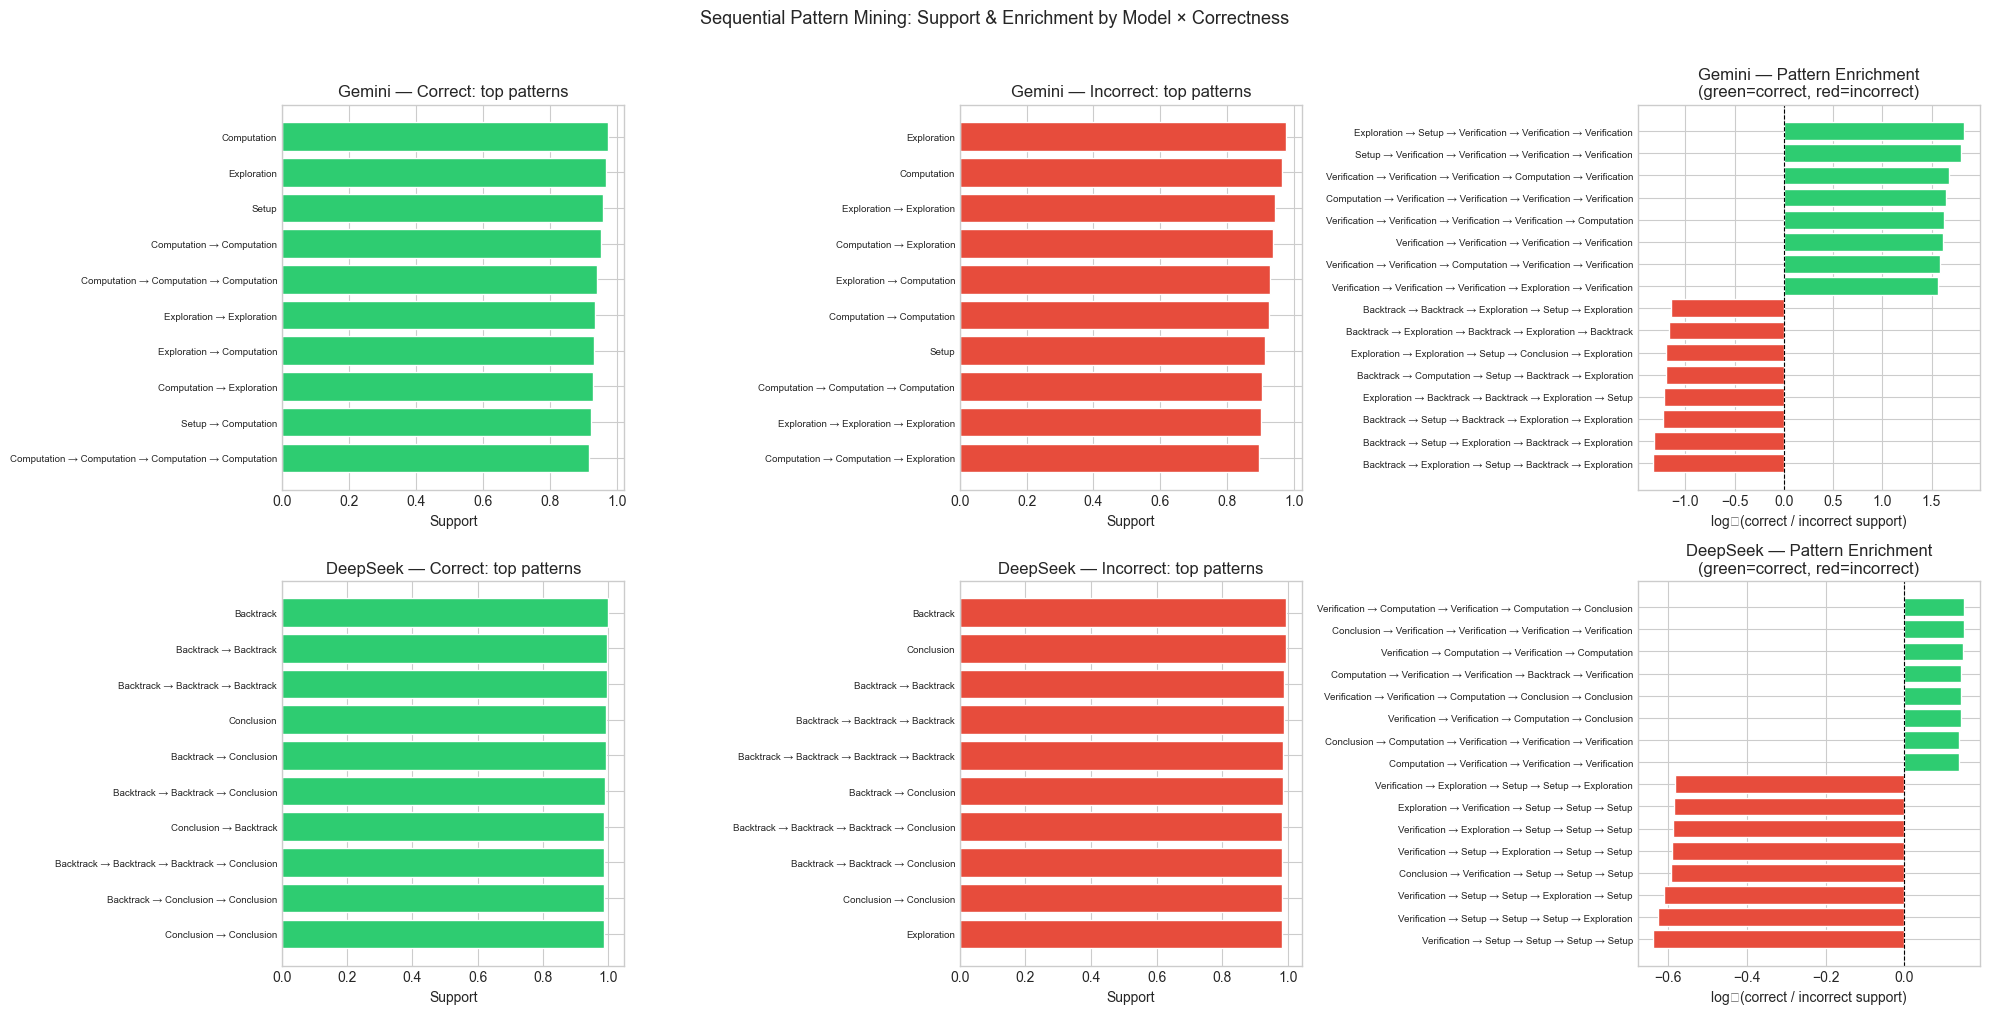

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EPS = 1e-9

def enrichment_table(c, i):
    """Return enrichment ratio table for patterns common to both splits."""
    common = c.index.intersection(i.index)
    if common.empty:
        return pd.DataFrame()
    ratio = (c[common] / (i[common] + EPS)).rename('ratio')
    return pd.concat(
        [c[common].rename('correct'), i[common].rename('incorrect'), ratio],
        axis=1,
    )


# ── Text summary ─────────────────────────────────────────────────────────────
if all(v.empty for v in pattern_results.values()):
    print('No patterns found in any split — check label parsing and split sizes.')
else:
    print('=== Patterns enriched in CORRECT vs INCORRECT traces ===\n')
    for mdl in ['gemini', 'deepseek']:
        c = pattern_results.get(f'{mdl}_C', pd.Series(dtype=float))
        i = pattern_results.get(f'{mdl}_I', pd.Series(dtype=float))

        if c.empty or i.empty:
            print(f'--- {mdl.upper()}: insufficient data for enrichment ---\n')
            continue

        tbl = enrichment_table(c, i)
        if tbl.empty:
            print(f'--- {mdl.upper()}: no overlapping patterns ---\n')
            continue

        print(f'--- {mdl.upper()}: Enriched in CORRECT ---')
        print(tbl.nlargest(6, 'ratio')[['correct', 'incorrect', 'ratio']].round(3).to_string())
        print(f'\n--- {mdl.upper()}: Enriched in INCORRECT ---')
        print(tbl.nsmallest(6, 'ratio')[['correct', 'incorrect', 'ratio']].round(3).to_string(), '\n')


# ── Visualisation: top-pattern supports + log2 enrichment ────────────────────
TOP_K    = 10
ENRICH_K = 8

models_with_data = [
    m for m in ['gemini', 'deepseek']
    if not pattern_results.get(f'{m}_C', pd.Series()).empty
    or not pattern_results.get(f'{m}_I', pd.Series()).empty
]

if models_with_data:
    n_rows = len(models_with_data)
    fig, axes = plt.subplots(n_rows, 3, figsize=(20, 5 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    titles = {'gemini': 'Gemini', 'deepseek': 'DeepSeek'}

    for row_idx, mdl in enumerate(models_with_data):
        c = pattern_results.get(f'{mdl}_C', pd.Series(dtype=float))
        i = pattern_results.get(f'{mdl}_I', pd.Series(dtype=float))

        # Panel 0 – correct top patterns
        ax0 = axes[row_idx, 0]
        if not c.empty:
            top_c = c.head(TOP_K)
            ax0.barh(top_c.index[::-1], top_c.values[::-1], color='#2ecc71', edgecolor='white')
            ax0.set_xlabel('Support')
        else:
            ax0.text(0.5, 0.5, 'No patterns', ha='center', va='center', transform=ax0.transAxes)
            ax0.axis('off')
        ax0.set_title(f"{titles[mdl]} — Correct: top patterns")
        ax0.tick_params(axis='y', labelsize=7)

        # Panel 1 – incorrect top patterns
        ax1 = axes[row_idx, 1]
        if not i.empty:
            top_i = i.head(TOP_K)
            ax1.barh(top_i.index[::-1], top_i.values[::-1], color='#e74c3c', edgecolor='white')
            ax1.set_xlabel('Support')
        else:
            ax1.text(0.5, 0.5, 'No patterns', ha='center', va='center', transform=ax1.transAxes)
            ax1.axis('off')
        ax1.set_title(f"{titles[mdl]} — Incorrect: top patterns")
        ax1.tick_params(axis='y', labelsize=7)

        # Panel 2 – enrichment bar chart
        ax2 = axes[row_idx, 2]
        tbl = enrichment_table(c, i) if (not c.empty and not i.empty) else pd.DataFrame()
        if not tbl.empty:
            top_pos = tbl['ratio'].nlargest(ENRICH_K)
            top_neg = tbl['ratio'].nsmallest(ENRICH_K)
            combined = pd.concat([top_pos, top_neg]).drop_duplicates().sort_values()
            colors = ['#2ecc71' if v >= 1 else '#e74c3c' for v in combined.values]
            ax2.barh(combined.index, np.log2(combined.values + EPS), color=colors, edgecolor='white')
            ax2.axvline(0, color='black', lw=0.8, ls='--')
            ax2.set_xlabel('log₂(correct / incorrect support)')
            ax2.tick_params(axis='y', labelsize=7)
        else:
            ax2.text(0.5, 0.5, 'No overlap', ha='center', va='center', transform=ax2.transAxes)
            ax2.axis('off')
        ax2.set_title(f"{titles[mdl]} — Pattern Enrichment\n(green=correct, red=incorrect)")

    plt.suptitle(
        'Sequential Pattern Mining: Support & Enrichment by Model × Correctness',
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.show()


## 11. Trace Editing Interventions

Since re-running Gemini / DeepSeek inference is not feasible here, we
instead use our **trained structural classifier (M2)** as a proxy:

1. Apply a structural edit to every label sequence  
2. Re-extract structural features from the edited sequences  
3. Predict correctness with M2 and compare to the unedited baseline  
4. Use McNemar's test to assess statistical significance

Large accuracy drops / gains provide evidence that the edited structural
elements are **causally relevant**, not epiphenomenal.

In [29]:
from statsmodels.stats.contingency_tables import mcnemar as mc_test

# Train M2 on full data (already done above — reuse or refit)
m2_full = Pipeline([("sc", StandardScaler()),
                    ("clf", LogisticRegression(max_iter=1000, C=1.0,
                                               random_state=RANDOM_SEED))])
m2_full.fit(X_struct, y)
baseline_pred = m2_full.predict(X_struct)
baseline_acc  = accuracy_score(y, baseline_pred)
print(f"Baseline classifier accuracy: {baseline_acc:.3f}")

def edit_sequence(labels: list, intervention: str) -> list:
    if intervention == "remove_verification":
        return [l for l in labels if l != "Verification"] or ["Computation"]
    if intervention == "remove_backtrack":
        return [l for l in labels if l != "Backtrack"] or ["Computation"]
    if intervention == "shuffle":
        s = labels[:]
        np.random.shuffle(s)
        return s
    if intervention == "inject_error_correction":
        # Insert Verification→Backtrack→Computation every 5 Computation steps
        out, cnt = [], 0
        for l in labels:
            out.append(l)
            if l == "Computation":
                cnt += 1
                if cnt % 5 == 0:
                    out += ["Verification", "Backtrack", "Computation"]
        return out
    return labels

interventions = {
    "remove_verification":    "Remove all Verification steps",
    "remove_backtrack":       "Remove all Backtrack steps",
    "shuffle":                "Shuffle step order (null control)",
    "inject_error_correction":"Inject Verif→Backtrack→Comp cycle",
}

Baseline classifier accuracy: 0.699


In [30]:
print(f"\n{'Intervention':<40} {'Acc':>6}  {'Δ':>7}  {'p (McNemar)':>13}  Sig")
print("─" * 76)

for key, desc in interventions.items():
    edited_feats = [
        structural_features(edit_sequence(row["labels"], key))
        for _, row in classified_df.iterrows()
    ]
    X_edit   = pd.DataFrame(edited_feats)[FEAT_COLS].values
    edit_pred= m2_full.predict(X_edit)
    edit_acc = accuracy_score(y, edit_pred)
    delta    = edit_acc - baseline_acc

    # McNemar table
    a = int(((baseline_pred==y) & (edit_pred!=y)).sum())
    b = int(((baseline_pred!=y) & (edit_pred==y)).sum())
    table = np.array([[0, a],[b, 0]])   # off-diagonal only matters for McNemar
    try:
        res = mc_test(table, exact=(a+b < 25))
        p   = res.pvalue
    except Exception:
        p   = float("nan")

    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
    print(f"  {desc:<38} {edit_acc:>6.3f}  {delta:>+7.3f}  {p:>13.4f}  {sig}")


Intervention                                Acc        Δ    p (McNemar)  Sig
────────────────────────────────────────────────────────────────────────────
  Remove all Verification steps           0.624   -0.075         0.0000  ***
  Remove all Backtrack steps              0.678   -0.020         0.0050  **
  Shuffle step order (null control)       0.696   -0.003         0.6056  ns
  Inject Verif→Backtrack→Comp cycle       0.695   -0.004         0.5627  ns


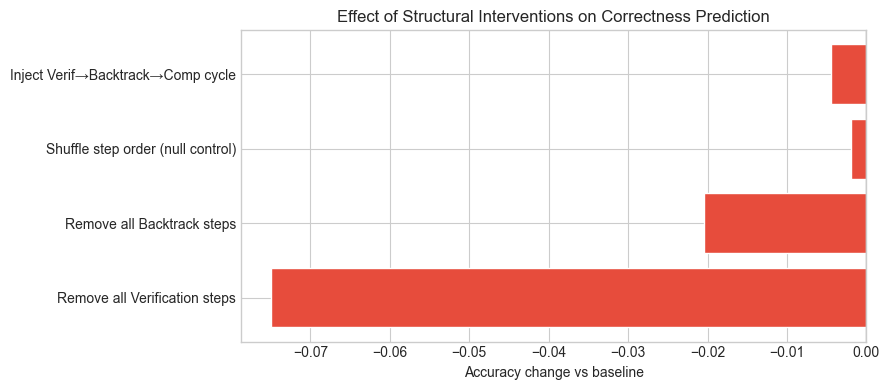

In [31]:
# ── Visual summary of intervention effects ──────────────────────────────────
deltas, labels_bar = [], []
for key, desc in interventions.items():
    ef = [structural_features(edit_sequence(r["labels"], key))
          for _, r in classified_df.iterrows()]
    Xe = pd.DataFrame(ef)[FEAT_COLS].values
    deltas.append(accuracy_score(y, m2_full.predict(Xe)) - baseline_acc)
    labels_bar.append(desc)

colors = ["#e74c3c" if d < 0 else "#2ecc71" for d in deltas]
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(labels_bar, deltas, color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Accuracy change vs baseline")
ax.set_title("Effect of Structural Interventions on Correctness Prediction")
plt.tight_layout(); plt.show()